# DeepPCB YOLOv8 Detection Baseline in Google Colab

This notebook is for the **DeepPCB COCO detection baseline only**.

- Model: `yolov8n.pt`
- Task: object detection
- Training style: fine-tuning / transfer learning from pretrained weights
- Dataset: `configs/deeppcb_coco_baseline.yaml`
- Scope: DeepPCB only, no PKU merge, no tiling, no segmentation, no severity yet


## Colab Setup Notes

Use one of these project access options:

1. Put the whole repo in Google Drive and mount Drive in Colab.
2. Clone your GitHub repo into `/content/`.
3. Upload the project folder manually if needed.

This notebook assumes **Google Drive** by default because it is the safest way to keep datasets, runs, and weights between sessions.

Important:

- The current DeepPCB COCO export has `trainval` and `test` splits.
- For this baseline workflow, `trainval` is used for training and `test` is reused as the validation/inference-check split.
- This keeps the workflow simple without changing the source dataset contents.


In [1]:
!pip install -q ultralytics==8.4.14 opencv-python pyyaml matplotlib

import platform
import sys
import torch

print('Python:', sys.version)
print('Platform:', platform.platform())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

if torch.cuda.is_available():
    !nvidia-smi
else:
    print('GPU not detected. In Colab, switch Runtime > Change runtime type > GPU before training.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00a 0:00:01
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA available: True
Sun Apr 26 13:23:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

## Mount Google Drive and Open the Repo

Update `PROJECT_ROOT` if your repo folder has a different Drive location.


In [2]:
from pathlib import Path

USE_DRIVE = True
PROJECT_ROOT = Path('/content/drive/MyDrive/PCB-Defect-Detector')  # change if needed

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

assert PROJECT_ROOT.exists(), f'Update PROJECT_ROOT to your repo folder: {PROJECT_ROOT}'

%cd $PROJECT_ROOT
print('Working directory:', PROJECT_ROOT)


Mounted at /content/drive
/content/drive/MyDrive/PCB-Defect-Detector
Working directory: /content/drive/MyDrive/PCB-Defect-Detector


## Prepare the DeepPCB YOLO Workspace

This runs the repo's DeepPCB preparation logic using the converted COCO config.
It does **not** start training yet.


In [3]:
!python scripts/deeppcb_yolov8_colab_train.py --prepare-only
!cat configs/deeppcb_yolov8_baseline_data.yaml


CONFIG=/content/drive/MyDrive/PCB-Defect-Detector/configs/deeppcb_coco_baseline.yaml
WORKSPACE=/content/drive/MyDrive/PCB-Defect-Detector/data/yolo_ready/deeppcb_yolov8_baseline
DATA_YAML=/content/drive/MyDrive/PCB-Defect-Detector/configs/deeppcb_yolov8_baseline_data.yaml
MODEL=yolov8n.pt
TRAIN_SOURCE_SPLIT=trainval
VAL_SOURCE_SPLIT=test
TEST_SOURCE_SPLIT=test
TRAIN_IMAGES=1000
TRAIN_ANNOTATIONS=6873
TRAIN_MISSING_IMAGE_REFS=0
TRAIN_MISSING_IMAGE_FILES=0
TRAIN_INVALID_CATEGORY_IDS=0
TRAIN_MALFORMED_BBOX=0
TRAIN_NONPOSITIVE_BBOX=0
TRAIN_OUT_OF_BOUNDS_BBOX=0
VAL_IMAGES=500
VAL_ANNOTATIONS=3140
VAL_MISSING_IMAGE_REFS=0
VAL_MISSING_IMAGE_FILES=0
VAL_INVALID_CATEGORY_IDS=0
VAL_MALFORMED_BBOX=0
VAL_NONPOSITIVE_BBOX=0
VAL_OUT_OF_BOUNDS_BBOX=0
TEST_IMAGES=500
TEST_ANNOTATIONS=3140
TEST_MISSING_IMAGE_REFS=0
TEST_MISSING_IMAGE_FILES=0
TEST_INVALID_CATEGORY_IDS=0
TEST_MALFORMED_BBOX=0
TEST_NONPOSITIVE_BBOX=0
TEST_OUT_OF_BOUNDS_BBOX=0
STATUS=DeepPCB YOLO workspace and training data YAML are ready 

## Baseline Training Settings

This is the first DeepPCB-only baseline run, so keep it short and practical.


In [4]:
MODEL = 'yolov8n.pt'
EPOCHS = 10
IMGSZ = 640
BATCH = 16
WORKERS = 2
DEVICE = '0'
FRACTION = 1.0
PATIENCE = 20
PROJECT_DIR = 'runs/deeppcb_baseline'
RUN_NAME = 'yolov8n_deeppcb_baseline_colab'

print({
    'model': MODEL,
    'epochs': EPOCHS,
    'imgsz': IMGSZ,
    'batch': BATCH,
    'workers': WORKERS,
    'device': DEVICE,
    'fraction': FRACTION,
    'patience': PATIENCE,
    'project_dir': PROJECT_DIR,
    'run_name': RUN_NAME,
})


{'model': 'yolov8n.pt', 'epochs': 10, 'imgsz': 640, 'batch': 16, 'workers': 2, 'device': '0', 'fraction': 1.0, 'patience': 20, 'project_dir': 'runs/deeppcb_baseline', 'run_name': 'yolov8n_deeppcb_baseline_colab'}


In [5]:
import subprocess

train_cmd = [
    'python', 'scripts/deeppcb_yolov8_colab_train.py',
    '--model', MODEL,
    '--epochs', str(EPOCHS),
    '--imgsz', str(IMGSZ),
    '--batch', str(BATCH),
    '--workers', str(WORKERS),
    '--device', DEVICE,
    '--fraction', str(FRACTION),
    '--patience', str(PATIENCE),
    '--project', PROJECT_DIR,
    '--name', RUN_NAME,
]

print('Running:', ' '.join(train_cmd))
subprocess.run(train_cmd, check=True)


Running: python scripts/deeppcb_yolov8_colab_train.py --model yolov8n.pt --epochs 10 --imgsz 640 --batch 16 --workers 2 --device 0 --fraction 1.0 --patience 20 --project runs/deeppcb_baseline --name yolov8n_deeppcb_baseline_colab


CompletedProcess(args=['python', 'scripts/deeppcb_yolov8_colab_train.py', '--model', 'yolov8n.pt', '--epochs', '10', '--imgsz', '640', '--batch', '16', '--workers', '2', '--device', '0', '--fraction', '1.0', '--patience', '20', '--project', 'runs/deeppcb_baseline', '--name', 'yolov8n_deeppcb_baseline_colab'], returncode=0)

## Check the Training Outputs

Ultralytics may place the run under `runs/detect/...`, so this cell checks both likely output locations.


In [6]:
from pathlib import Path

candidate_run_dirs = [
    Path(PROJECT_DIR) / RUN_NAME,
    Path('runs/detect') / PROJECT_DIR / RUN_NAME,
]

RUN_DIR = None
for candidate in candidate_run_dirs:
    if candidate.exists():
        RUN_DIR = candidate
        break

assert RUN_DIR is not None, 'Training run folder not found yet.'

print('Run directory:', RUN_DIR)
print('Best weights:', RUN_DIR / 'weights' / 'best.pt')
print('Last weights:', RUN_DIR / 'weights' / 'last.pt')

results_csv = RUN_DIR / 'results.csv'
if results_csv.exists():
    import pandas as pd
    display(pd.read_csv(results_csv).tail())


Run directory: runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab
Best weights: runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/best.pt
Last weights: runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/last.pt


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
5,6,169.753,1.15789,1.01613,1.00156,0.90819,0.86755,0.92774,0.57404,1.28119,0.84327,1.00706,0.000505,0.000505,0.000505
6,7,197.051,1.13913,0.94594,0.98684,0.90131,0.88016,0.94006,0.69355,0.92857,0.72283,0.93430,0.000406,0.000406,0.000406
7,8,224.330,1.05845,0.87656,0.96423,0.91328,0.90054,0.94881,0.65643,1.07587,0.70745,0.96523,0.000307,0.000307,0.000307
8,9,249.531,1.02627,0.81813,0.95602,0.91603,0.90340,0.95457,0.70216,0.92644,0.65024,0.92894,0.000208,0.000208,0.000208
9,10,277.122,0.99683,0.78994,0.95062,0.91156,0.91519,0.95582,0.71398,0.89814,0.62905,0.91828,0.000109,0.000109,0.000109


## Quick Validation / Inference Check

This uses a few DeepPCB test images, which are also the validation split for this baseline workflow.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Results saved to /content/drive/MyDrive/PCB-Defect-Detector/data/inspection_outputs/yolov8n_deeppcb_baseline_colab_predictions
Prediction directory: /content/drive/MyDrive/PCB-Defect-Detector/data/inspection_outputs/yolov8n_deeppcb_baseline_colab_predictions
Predictions generated for 8 images


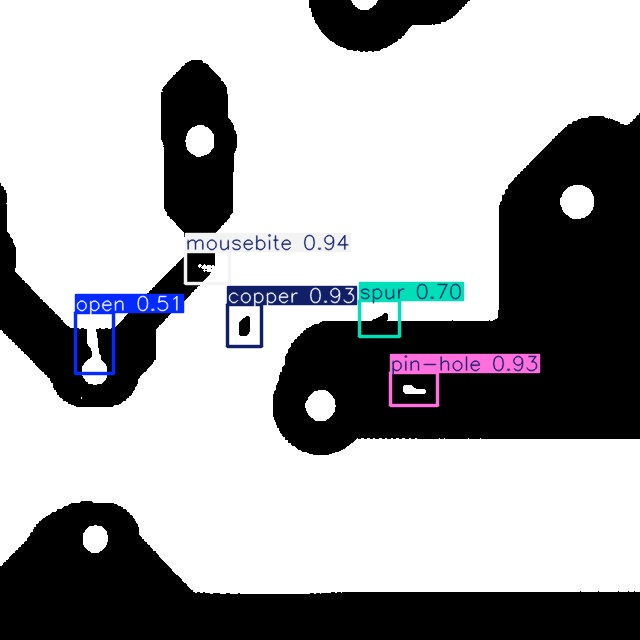

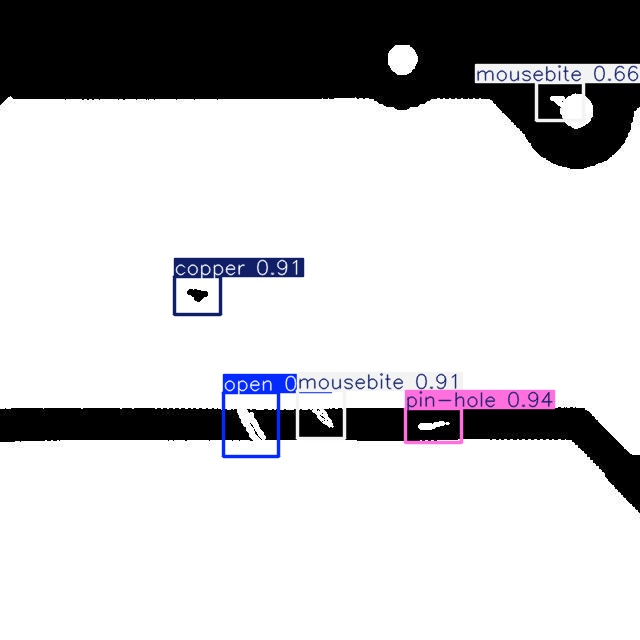

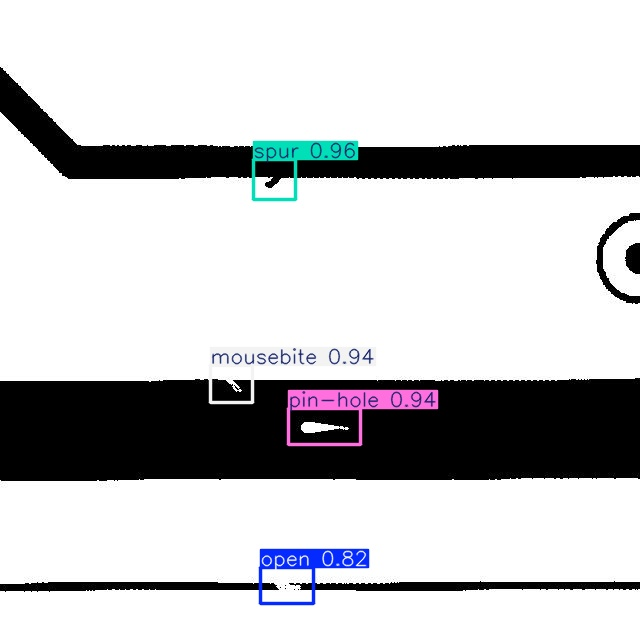

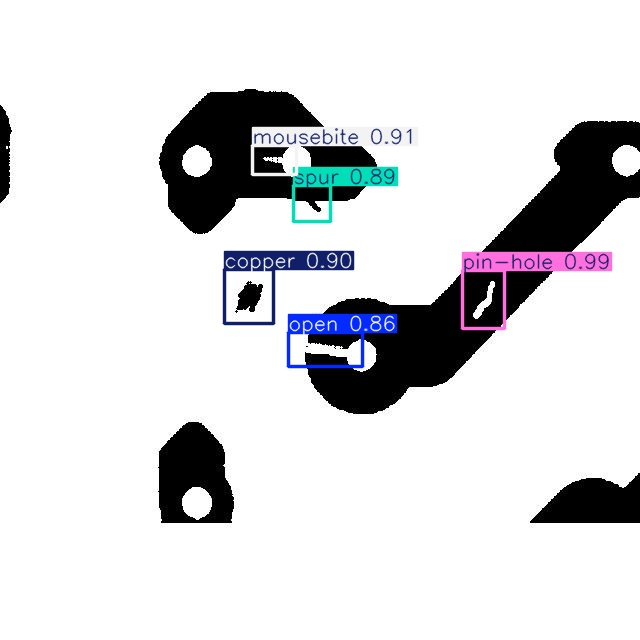

In [7]:
from pathlib import Path
from IPython.display import Image, display
from ultralytics import YOLO

best_weights = RUN_DIR / 'weights' / 'best.pt'
assert best_weights.exists(), f'Missing best weights: {best_weights}'

val_dir = Path('data/coco_master/deeppcb_full/images/test')
sample_images = sorted(val_dir.rglob('*.jpg'))[:8]
assert sample_images, f'No DeepPCB test images found in {val_dir}'

pred_root = (Path.cwd() / 'data' / 'inspection_outputs').resolve()
pred_name = f'{RUN_NAME}_predictions'

model = YOLO(str(best_weights))
results = model.predict(
    source=[str(path) for path in sample_images],
    imgsz=IMGSZ,
    conf=0.25,
    device=DEVICE,
    save=True,
    project=str(pred_root),
    name=pred_name,
    exist_ok=True,
    verbose=False,
)

pred_dir = pred_root / pred_name
print('Prediction directory:', pred_dir)
print('Predictions generated for', len(results), 'images')

for image_path in sorted(pred_dir.glob('*.jpg'))[:4]:
    display(Image(filename=str(image_path)))


## Notes

- This notebook stays DeepPCB-only and detection-only.
- The first DeepPCB run name is `yolov8n_deeppcb_baseline_colab`.
- Training artifacts will be saved under `runs/deeppcb_baseline` or `runs/detect/runs/deeppcb_baseline`, including `best.pt`, `last.pt`, and `results.csv`.
- Prediction images will be saved under `data/inspection_outputs/yolov8n_deeppcb_baseline_colab_predictions`.
- PKU, dataset merging, tiling, segmentation, severity, and synthetic augmentation stay for later steps.
- If you later run a longer DeepPCB baseline, change `RUN_NAME` so the first run stays preserved.
